<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

# 05 · BaseDynamics: relaxation and molecular dynamics

**Goal:** Use the same public dynamics lifecycle for a fast Lennard-Jones argon diagnostic and a supported molecular `FIRE2` relaxation.

**Core concepts:** `BaseDynamics` owns the step loop, model evaluation, hooks, convergence, and in-place `Batch` state. `FIRE2`, `NVE`, and `NVTLangevin` supply different numerical updates. `FusedStage` lets compatible methods share one active batch and model path.

We reuse [Part 01's `AtomicData`, `Batch`, selection, and recovery](../01-atomicdata-batch/atomicdata-and-batch.ipynb), [Part 03's configured model](../03-model-interfaces-composition/model-interfaces-composition.ipynb), and [Part 04's hook registration](../04-hooks/hooks.ipynb). This part adds **one new capability**: evolve a `Batch` through optimization and molecular-dynamics workflows. The [Core Playbook](../00-core-playbook/alchemi-core-playbook.ipynb) shows the short route; this deep dive measures convergence and conservation explicitly.

<details>
<summary>Where NVIDIA ALCHEMI fits (recap)</summary>

[ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together Python building blocks, accelerated kernels, and deployable services for atomistic workflows.

- **ALCHEMI Toolkit** is a GPU-first Python framework with a unified, composable API for MLIPs and custom models. It provides GPU-native atomic data and batching, model adapters, MD classes, hooks, model training,  and single- to multi-GPU pipelines.   
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit) · [Docs](https://nvidia.github.io/nvalchemi-toolkit/) · Apache 2.0 license

- **Toolkit-Ops** supplies GPU-optimized, batched operations for neighbor lists, dynamics, dispersion, and electrostatics, with PyTorch and JAX bindings.    
[GitHub repo](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Docs](https://nvidia.github.io/nvalchemi-toolkit-ops/) · Apache 2.0 license

- **ALCHEMI NIM microservices** package supported atomistic workflows as cloud-ready services. The current catalog includes Batched Geometry Relaxation for structural optimization and Batched Molecular Dynamics.  Self-hosting uses an NVIDIA AI Enterprise license.   
 [Transparency card](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/1.0.0/ai-transparency-card/overview.html) · [Docs](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html)
</details>

In [1]:
import helpers
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from nvalchemi.data import AtomicData, Batch
from nvalchemi.dynamics import (
    FIRE2,
    NVE,
    BaseDynamics,
    ConvergenceHook,
    DynamicsStage,
    FusedStage,
    NVTLangevin,
    initialize_velocities,
)
from nvalchemi.dynamics.hooks import EnergyDriftMonitorHook
from nvalchemi.hooks import WrapPeriodicHook
from nvalchemi.models import AIMNet2Wrapper, LennardJonesModelWrapper
from nvalchemi.neighbors import compute_neighbors

In [2]:
LABELS = (
    "Ethyne", "Acetonitrile", "Methanol", "Acetaldehyde",
    "Acetamide", "Pyridine", "Phenol", "2,3-dimethylbutane",
)
FMAX_TARGET_EV_A = 0.15
MAX_STEPS = 120
ARGON_TEMPERATURE_K = 50.0
NVE_DIAGNOSTIC_STEPS = 200
DRIFT_LIMIT_EV_ATOM_UPDATE = 1e-4
NVT_DEMO_STEPS = 40
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
molecules, molecule_table = helpers.configure_presentation(LABELS)

## Fast mechanics: Lennard-Jones argon

We first switch from molecules and AIMNet2 to the official Lennard-Jones argon route. The model uses `epsilon = 0.0104 eV`, `sigma = 3.40 Å`, and `cutoff = 8.5 Å`. Its small deterministic workload makes the `BaseDynamics` mechanics easy to inspect before the molecular calculation.

The graph contains 27 periodic argon atoms on a simple-cubic lattice. Simple-cubic Lennard-Jones argon is mechanically unstable over long runs, so this is a bounded integration example rather than a crystal model for materials conclusions.

The first question is narrow: what does one `NVE` stage read, update, and record?

In [4]:
LJ_EPSILON_EV = 0.0104
LJ_SIGMA_A = 3.40
LJ_CUTOFF_A = 8.5
ARGON_MASS_AMU = 39.948
lj_model = LennardJonesModelWrapper(
    epsilon=LJ_EPSILON_EV, sigma=LJ_SIGMA_A, cutoff=LJ_CUTOFF_A
).to(device)

In [5]:
argon_spacing_a = 2 ** (1 / 6) * LJ_SIGMA_A
argon_positions, argon_cell = helpers.periodic_argon_geometry(
    n_side=3,
    spacing=argon_spacing_a,
    device=device,
    dtype=torch.float32,
)

In [6]:
argon_data = AtomicData(
    positions=argon_positions,
    atomic_numbers=torch.full((27,), 18, device=device, dtype=torch.long),
    atomic_masses=torch.full((27,), ARGON_MASS_AMU, device=device),
    forces=torch.zeros_like(argon_positions),
    energy=torch.zeros(1, 1, device=device),
    cell=argon_cell,
    pbc=torch.ones(1, 3, device=device, dtype=torch.bool),
)
argon_data.use_default_velocities()
argon_data.add_system_property(
    "status", torch.zeros(1, 1, device=device, dtype=torch.long)
)
argon_batch = Batch.from_data_list([argon_data], device=device)

### Initialize mass-aware velocities

`initialize_velocities(...)` writes into the existing velocity tensor. It samples a seeded thermal distribution for each graph, removes center-of-mass translation, and rescales the result to the requested temperature. Velocities use `sqrt(eV/amu)`, so `0.5 * mass * velocity²` is in eV.

In [7]:
initialize_velocities(
    argon_batch.velocities,
    argon_batch.atomic_masses,
    torch.tensor([ARGON_TEMPERATURE_K], device=device),
    argon_batch.batch_idx,
    random_seed=42,
    remove_com=True,
    rescale=True,
)

In [8]:
pd.Series({
    "graphs / atoms": f"{argon_batch.num_graphs} / {argon_batch.num_nodes}",
    "positions": f"{tuple(argon_batch.positions.shape)} Å",
    "velocities": f"{tuple(argon_batch.velocities.shape)} sqrt(eV/amu)",
    "forces": f"{tuple(argon_batch.forces.shape)} eV/Å",
    "energy": f"{tuple(argon_batch.energy.shape)} eV",
    "cell": f"{tuple(argon_batch.cell.shape)} Å",
    "device / dtype": f"{argon_batch.device} / {argon_batch.positions.dtype}",
}, name="value").to_frame()

,value
graphs / atoms,1 / 27
positions,"(27, 3) Å"
velocities,"(27, 3) sqrt(eV/amu)"
forces,"(27, 3) eV/Å"
energy,"(1, 1) eV"
cell,"(1, 3, 3) Å"
device / dtype,cuda / torch.float32


### A five-update `NVE` trace

`NVE` uses Velocity Verlet. Model-provided hooks refresh neighbors before force evaluation, `WrapPeriodicHook` folds positions back into the cell after the position/velocity update, and a small observation hook records potential, kinetic, and total energy.

Five updates expose the lifecycle and tensor ownership. They cannot establish equilibration, useful-time energy conservation, or production dynamics.

In [9]:
nve_trace = helpers.DynamicsTrace(("argon",), store_positions=True)
nve = NVE(
    model=lj_model,
    dt=1.0,
    n_steps=5,
    hooks=[
        *lj_model.make_neighbor_hooks(),
        WrapPeriodicHook(stage=DynamicsStage.AFTER_POST_UPDATE),
        nve_trace,
    ],
)

In [10]:
compute_neighbors(argon_batch, config=lj_model.model_config.neighbor_config)
nve.compute(argon_batch)
nve_trace.record(argon_batch, completed_update=0)

In [11]:
nve_input_short = argon_batch.clone()
nve_result = nve.run(nve_input_short)

In [12]:
nve_short_history = nve_trace.history_frame()
nve_short_table = nve_short_history[
    [
        "completed update (1-based)", "potential energy (eV)",
        "kinetic energy (eV)", "total energy (eV)", "temperature (K)",
    ]
]

In [13]:
display(nve_short_table)

,completed update (1-based),potential energy (eV),kinetic energy (eV),total energy (eV),temperature (K)
0,0,-1.345054,0.174501,-1.170553,49.999996
1,1,-1.345049,0.174497,-1.170553,49.998749
2,2,-1.345036,0.174484,-1.170553,49.994987
3,3,-1.345014,0.174462,-1.170553,49.988716
4,4,-1.344983,0.174431,-1.170553,49.979904
5,5,-1.344944,0.174391,-1.170553,49.968548


The five-update trace confirms that `BaseDynamics.run(...)` advanced one prepared `Batch`, called the Lennard-Jones model through the neighbor hooks, and left current positions, velocities, forces, and energy in the same container. The table is execution evidence, not a conservation claim.

### A 200-update conservation diagnostic

The official NVE example extends the same setup to 200 updates. Here `EnergyDriftMonitorHook` checks a per-atom-per-update threshold while a trace records all energy components. This tests the chosen model, starting state, and `1 fs` timestep over a bounded diagnostic interval.

In [14]:
conservation_trace = helpers.DynamicsTrace(
    ("argon",), store_positions=True, position_frequency=100
)
drift_hook = EnergyDriftMonitorHook(
    threshold=DRIFT_LIMIT_EV_ATOM_UPDATE,
    metric="per_atom_per_step",
    action="warn",
    frequency=20,
)
nve_diagnostic = NVE(
    model=lj_model, dt=1.0, n_steps=NVE_DIAGNOSTIC_STEPS,
    hooks=[*lj_model.make_neighbor_hooks(),
           WrapPeriodicHook(stage=DynamicsStage.AFTER_POST_UPDATE),
           drift_hook, conservation_trace],
)

In [15]:
nve_input = argon_batch.clone()
compute_neighbors(nve_input, config=lj_model.model_config.neighbor_config)
nve_diagnostic.compute(nve_input)
conservation_trace.record(nve_input, completed_update=0)

In [16]:
nve_diagnostic_result = nve_diagnostic.run(nve_input)

In [17]:
conservation_history = conservation_trace.history_frame()
conservation_summary = helpers.energy_conservation_summary(
    conservation_history, atoms_per_system=nve_diagnostic_result.num_nodes
).to_frame()
conservation_summary["value"] = conservation_summary["value"].astype(object)
measured_drift = conservation_summary.loc[
    "maximum |ΔE| per atom per update (eV/atom/update)", "value"
]
conservation_summary.loc["configured drift limit (eV/atom/update)", "value"] = (
    DRIFT_LIMIT_EV_ATOM_UPDATE
)
conservation_summary.loc["within configured drift limit", "value"] = bool(
    measured_drift <= DRIFT_LIMIT_EV_ATOM_UPDATE
)
conservation_summary.loc["finite positions", "value"] = bool(
    torch.isfinite(nve_diagnostic_result.positions).all()
)

In [18]:
display(conservation_summary)

,value
updates,200.0
maximum |ΔE| (eV),0.023742
maximum |ΔE| per atom (meV/atom),0.87935
maximum |ΔE| per atom per update (eV/atom/update),0.000004
final temperature (K),19.823328
configured drift limit (eV/atom/update),0.0001
within configured drift limit,True
finite positions,True


How do potential and kinetic energy exchange, and how far does total energy move from its initial value?

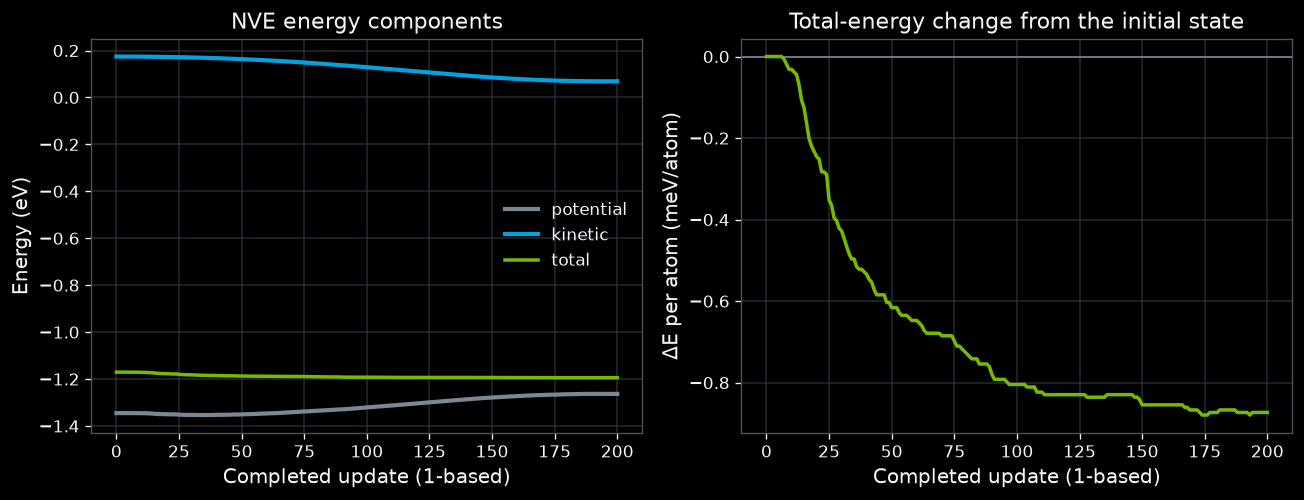

In [19]:
energy_figure = helpers.plot_energy_conservation(
    conservation_history, atoms_per_system=nve_diagnostic_result.num_nodes
)
display(
    energy_figure,
    metadata={"image/png": {"alt": "Lennard-Jones argon potential, kinetic, and total energy with total-energy change per atom over 200 NVE updates."}},
)
plt.close(energy_figure)

Potential and kinetic energy exchange while the green total-energy trace stays near its initial value by the measured amount in the table. This 200-update result is an integration diagnostic for one timestep and starting state. It is not equilibration, not a production trajectory, and not evidence that simple-cubic argon is a stable phase.

What moved inside the periodic box during the same diagnostic?

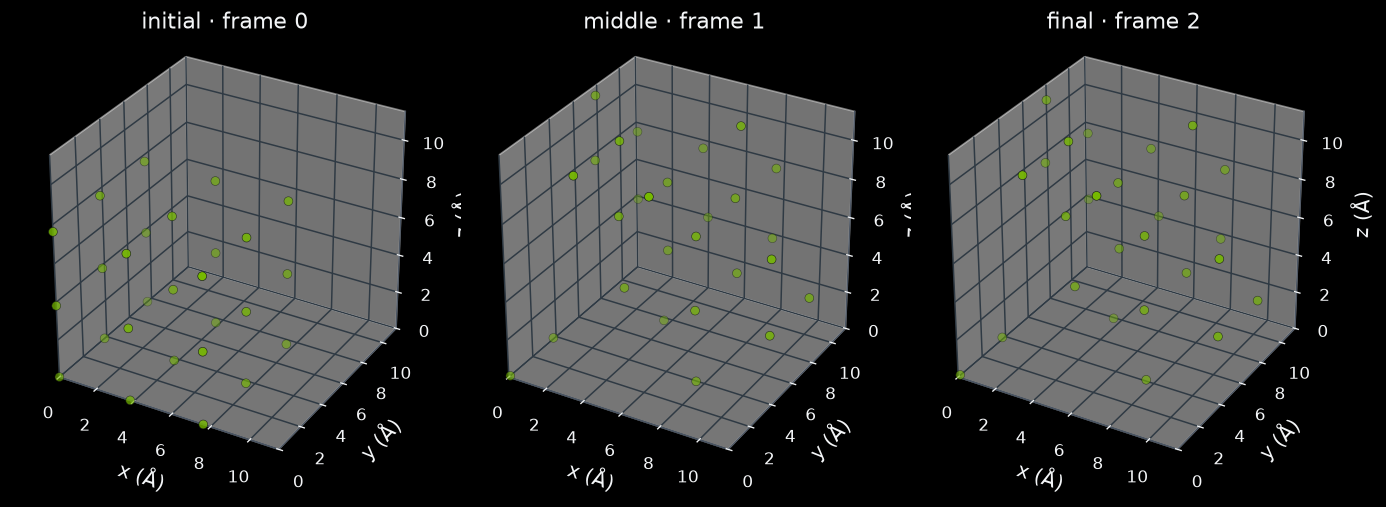

In [20]:
trajectory_figure = helpers.plot_argon_trajectory(
    conservation_trace.position_frames,
    box_size=float(argon_cell[0, 0, 0].detach().cpu()),
)
display(
    trajectory_figure,
    metadata={"image/png": {"alt": "Initial, middle, and final wrapped positions of 27 periodic Lennard-Jones argon atoms."}},
)
plt.close(trajectory_figure)

The three panels show matched wrapped coordinates at update 0, 100, and 200. They help catch large displacement or boundary errors; they do not turn a short trace into sampled science.

**Go deeper:** The [official NVE energy-conservation example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/04_nve_energy_conservation.html) explains the Lennard-Jones setup, wrap hook, and drift monitor.

### `NVTLangevin`: controlled-temperature mechanics

`NVTLangevin` uses a BAOAB splitting. Conservative forces still come from the model, while friction removes kinetic energy and seeded Gaussian noise returns energy from a heat bath. Larger friction couples the system more strongly and shortens dynamical correlations.

Follow the official NVT route with a fresh nonperiodic simple-cubic cluster at `1.1 × r_min`. Start near `5 K`, couple it to a `50 K` bath for 40 updates, and inspect the instantaneous kinetic temperature. The plotted temperature follows Toolkit's unconstrained `3N` convention; constrained systems need a corrected degree-of-freedom count. This short stage exercises the API; it does not demonstrate equilibration.

In [21]:
nvt_data = AtomicData(
    positions=1.1 * argon_positions,
    atomic_numbers=torch.full((27,), 18, device=device, dtype=torch.long),
    atomic_masses=torch.full((27,), ARGON_MASS_AMU, device=device),
    forces=torch.zeros_like(argon_positions),
    energy=torch.zeros(1, 1, device=device),
)
nvt_data.use_default_velocities()
nvt_data.add_system_property(
    "status", torch.zeros(1, 1, device=device, dtype=torch.long)
)
nvt_input = Batch.from_data_list([nvt_data], device=device)
initialize_velocities(
    nvt_input.velocities,
    nvt_input.atomic_masses,
    torch.tensor([5.0], device=device),
    nvt_input.batch_idx,
    random_seed=7,
    remove_com=True, rescale=True,
)

In [22]:
nvt_trace = helpers.DynamicsTrace(("argon",))
nvt = NVTLangevin(
    model=lj_model,
    dt=0.5,
    temperature=ARGON_TEMPERATURE_K,
    friction=0.5,
    random_seed=42,
    n_steps=NVT_DEMO_STEPS,
    hooks=[*lj_model.make_neighbor_hooks(), nvt_trace],
)

In [23]:
compute_neighbors(nvt_input, config=lj_model.model_config.neighbor_config)
nvt.compute(nvt_input)
nvt_trace.record(nvt_input, completed_update=0)

In [24]:
nvt_result = nvt.run(nvt_input)

In [25]:
nvt_history = nvt_trace.history_frame()
nvt_endpoints = nvt_history.iloc[[0, -1]][
    [
        "completed update (1-based)", "potential energy (eV)",
        "kinetic energy (eV)", "total energy (eV)", "temperature (K)",
    ]
]

In [26]:
display(nvt_endpoints)

,completed update (1-based),potential energy (eV),kinetic energy (eV),total energy (eV),temperature (K)
0,0,-0.575717,0.017450,-0.558267,5.000000
40,40,-0.576430,0.140195,-0.436235,40.170277


How does the instantaneous temperature respond to the seeded Langevin bath over this short interval?

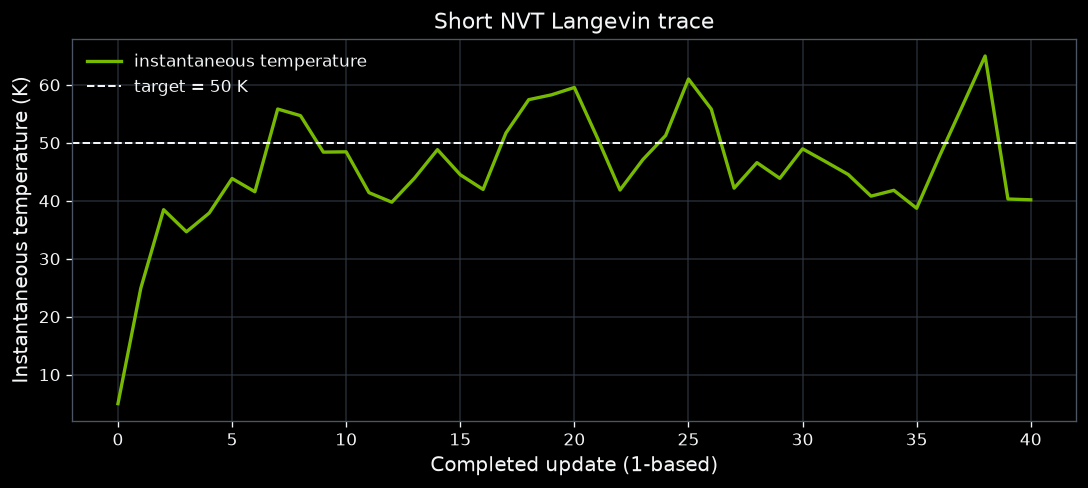

In [27]:
temperature_figure = helpers.plot_temperature_history(
    nvt_history, target=ARGON_TEMPERATURE_K
)
display(
    temperature_figure,
    metadata={"image/png": {"alt": "Instantaneous temperature of a short Lennard-Jones argon NVT Langevin trace and the 50 kelvin target."}},
)
plt.close(temperature_figure)

The bath changes the kinetic temperature through friction and random forcing, so total system energy is not the NVT conservation target. Forty updates are too short to establish a stationary temperature distribution, decorrelation, or equilibration.

**Go deeper:** The [official NVT Langevin example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/05_nvt_langevin.html) follows thermalization for a longer interval and explains the friction timescale.

### `FusedStage`: several methods, one active batch

The `+` operator composes compatible dynamics methods on one device. Each graph carries an integer status: status 0 selects the first method, status 1 selects the second, and the fused exit status is one past the last method. Masked updates change only graphs assigned to a method.

In [28]:
nvt_stage = NVTLangevin(
    model=lj_model, dt=0.5, temperature=50.0, friction=0.1,
    random_seed=19, n_steps=10,
)
nve_stage = NVE(model=lj_model, dt=0.5, n_steps=10)
fused_stage = nvt_stage + nve_stage
for hook in lj_model.make_neighbor_hooks():
    fused_stage.register_fused_hook(hook)

In [29]:
fused_stage_table = pd.DataFrame(
    [
        {"status": status, "method": type(stage).__name__,
         "model is shared": stage.model is lj_model}
        for status, stage in fused_stage.sub_stages
    ]
)
fused_stage_properties = {
    "is FusedStage": isinstance(fused_stage, FusedStage),
    "entry / exit status": (fused_stage.entry_status, fused_stage.exit_status),
    "outer model is shared": fused_stage.model is lj_model,
}

In [30]:
display(fused_stage_table)
fused_stage_properties

,status,method,model is shared
0,0,NVTLangevin,True
1,1,NVE,True


{'is FusedStage': True,
 'entry / exit status': (0, 2),
 'outer model is shared': True}

`FusedStage` keeps one active `Batch` and performs one shared model evaluation per fused update. It then applies each method through a status mask. The outer stage takes the model from its first sub-stage, so every sub-stage must use the same model and compatible device path. The `+` operator does not switch potentials.

This lesson stops at construction and the status/masking contract. Part 06 owns inflight refill, buffers, compilation, profiling, and complete GPU execution measurements.

**Go deeper:** Read the [official FusedStage example](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/01_multistage_pipeline.html) and [single-GPU orchestration guide](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/fused_stage.html).

### Where NPT fits

`NPT` extends the same lifecycle to variable-cell dynamics. An MTK barostat propagates the cell and particle coordinates toward a target pressure, while Nosé-Hoover chains control particle and cell temperatures. The model requires `stress` in addition to energy and forces, and the batch must carry a periodic cell plus writable stress storage.

We do not run NPT here. A valid mechanics check brackets equilibrium volume with compressed and expanded stable FCC cells and verifies that they move in opposite directions. A short volume trace cannot support a melting-point claim; melting-point estimation needs a separate R&D application with phase criteria, equilibration, finite-size checks, and uncertainty analysis.

**Go deeper:** See the [official NPT barostat validation](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/03_npt_barostat_validation.html). A future R&D melting-point application is in progress.

## Molecular interpretation: supported AIMNet2 relaxation

The scientific system now changes from periodic Lennard-Jones argon to eight finite neutral H/C/N/O molecules from the curated [NCI Atlas](https://github.com/Honza-R/NCIAtlas) subset ([CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)) and a pinned AIMNet2 checkpoint. The reusable objects remain the same: one model, one `Batch`, staged hooks, and a `BaseDynamics` subclass.

The question is concrete: **which molecules reach the same maximum-force target within one bounded `FIRE2` run?**

The molecules span 4–20 atoms. AIMNet2 supplies energy in eV and forces in eV/Å. This calculation interprets public workflow behavior within the checkpoint's supported elements and the selected neutral finite-molecule scope; it does not establish broader model accuracy.

In [31]:
atomic_records = [
    AtomicData.from_atoms(molecule, device=device, dtype=torch.float32)
    for molecule in molecules
]

In [32]:
for record in atomic_records:
    record.use_default_velocities()
    record.add_node_property("forces", torch.zeros_like(record.positions))
    record.add_system_property("energy", torch.zeros(1, 1, device=device, dtype=record.positions.dtype))
    record.add_system_property("status", torch.zeros(1, 1, device=device, dtype=torch.long))

`AtomicData.from_atoms(...)` rebuilds every structure from the fresh-kernel input. The next cell packs them in source order. Zero velocities, force and energy buffers, and integer status are writable workflow state; they are not measured results yet.

In [33]:
starting_batch = Batch.from_data_list(atomic_records, device=device)
starting_batch.num_graphs, starting_batch.num_nodes, starting_batch.device

(8, 76, device(type='cuda'))

### Inspect the writable workflow state

`Batch.keys` groups fields by storage level. FIRE2 will read and update these real tensors in place.

In [34]:
{level: sorted(fields) for level, fields in starting_batch.keys.items()}

{'node': ['atom_categories',
  'atomic_masses',
  'atomic_numbers',
  'forces',
  'positions',
  'velocities'],
 'edge': [],
 'system': ['charge', 'energy', 'status']}

In [35]:
batch_field_table = pd.DataFrame(
    [
        ("positions", tuple(starting_batch.positions.shape), "node", "Å"),
        ("velocities", tuple(starting_batch.velocities.shape), "node", "sqrt(eV/amu)"),
        ("forces", tuple(starting_batch.forces.shape), "node", "eV/Å"),
        ("energy", tuple(starting_batch.energy.shape), "system", "eV"),
        ("status", tuple(starting_batch.status.shape), "system", "integer state"),
    ],
    columns=["field", "shape", "level", "unit or meaning"],
).set_index("field")

In [36]:
batch_field_table

,shape,level,unit or meaning
field,,,
positions,"(76, 3)",node,Å
velocities,"(76, 3)",node,sqrt(eV/amu)
forces,"(76, 3)",node,eV/Å
energy,"(8, 1)",system,eV
status,"(8, 1)",system,integer state


In [37]:
model = AIMNet2Wrapper.from_checkpoint(
    helpers.model_checkpoint(), device=device, compile_model=False
).eval()
model = helpers.freeze_model(model)

In [38]:
model.set_config("active_outputs", {"energy", "forces"})
model.model_config.active_outputs, model.model_config.neighbor_config

({'energy', 'forces'},
 NeighborConfig(cutoff=5.0, format=<NeighborListFormat.MATRIX: 'matrix'>, half_list=False, skin=0.0))

### Confirm the model used by this run

Part 03 established how to inspect adapters. Here we only reactivate the reproducibility facts needed for dynamics. The exact checkpoint is [`aimnet2-wb97m-d3_0`, AIMNet2 ωB97M-D3 ensemble member 0](https://isayevlab.github.io/aimnetcentral/models/aimnet2/) from the AIMNet project; its model weights are MIT-licensed.

In [39]:
config = model.model_config
neighbor = config.neighbor_config
parameter = next(model.parameters())
model_identity = pd.Series({
    "checkpoint": helpers.MODEL_ALIAS,
    "source / license": "AIMNetCentral / MIT model weights",
    "selected scope": "finite neutral H/C/N/O molecules; interface demonstration",
    "supported elements": "H, B, C, N, O, F, Si, P, S, Cl, As, Se, Br, I",
    "precision / device": f"{parameter.dtype} / {parameter.device}",
    "active outputs": sorted(config.active_outputs),
    "neighbors": f"{neighbor.cutoff:g} Å · {neighbor.format.value} · full list",
    "wrapper Coulomb / dispersion": "disabled / disabled",
}, name="value").to_frame()

In [40]:
model_identity

,value
checkpoint,aimnet2-wb97m-d3_0
source / license,AIMNetCentral / MIT model weights
selected scope,finite neutral H/C/N/O molecules; interface de...
supported elements,"H, B, C, N, O, F, Si, P, S, Cl, As, Se, Br, I"
precision / device,torch.float32 / cuda:0
active outputs,"[energy, forces]"
neighbors,5 Å · matrix · full list
wrapper Coulomb / dispersion,disabled / disabled


The checkpoint name records its reference method; this standalone Toolkit wrapper disables external long-range Coulomb and D3 contributions. Compose those separately when the scientific workflow requires them. This lesson deliberately limits its claim to exercising the public dynamics interface on supported finite neutral H/C/N/O inputs.

### Register workflow hooks and configure convergence

`model.make_neighbor_hooks()` supplies neighbor refresh. A registered status hook migrates systems from status 0 to 1, and a registered monitor records completed updates. The detector is configured separately through `convergence_hook=`; it returns indices from `step(...)` and supports the host stopping check in `run(...)`.

In [41]:
neighbor_hooks = model.make_neighbor_hooks()
status_hook = ConvergenceHook.from_fmax(
    FMAX_TARGET_EV_A, source_status=0, target_status=1
)
convergence_check = ConvergenceHook.from_fmax(FMAX_TARGET_EV_A)
monitor = helpers.RelaxationMonitor(LABELS, total_steps=MAX_STEPS)

Inspect only the objects passed through `hooks=` in the next table. Their stage and frequency fields control registry dispatch. Part 04 exposed zero-based callback `ctx.step_count`; the monitor adds one and labels the learner-facing value `completed update (1-based)`.

In [42]:
registered_hook_objects = [*neighbor_hooks, status_hook, monitor]
registered_hook_table = pd.DataFrame(
    [{
        "object": type(hook).__name__, "ownership": "hooks= registry",
        "dispatch stage": hook.stage.name, "dispatch frequency": hook.frequency,
        "source status": getattr(hook, "source_status", None),
        "target status": getattr(hook, "target_status", None),
    } for hook in registered_hook_objects]
)

In [43]:
registered_hook_table

,object,ownership,dispatch stage,dispatch frequency,source status,target status
0,NeighborListHook,hooks= registry,BEFORE_COMPUTE,1,NaN,NaN
1,ConvergenceHook,hooks= registry,AFTER_STEP,1,0.0,1.0
2,RelaxationMonitor,hooks= registry,AFTER_STEP,1,NaN,NaN


### Inspect the host convergence detector

The same `ConvergenceHook` class can serve two roles. Here `convergence_check` is not registered in `hooks=`: after `AFTER_STEP` dispatch, `BaseDynamics` calls its `evaluate(batch)` directly. Its stage and frequency fields describe registry use and do not schedule this host convergence evaluation.

In [44]:
detector_table = pd.DataFrame([{
    "object": type(convergence_check).__name__,
    "ownership": "convergence_hook= host detector",
    "evaluation": "evaluate(batch) after AFTER_STEP",
    "status migration": "none",
    "stage field": convergence_check.stage.name,
    "frequency field": convergence_check.frequency,
    "fields schedule host evaluation": False,
}])

In [45]:
detector_table

,object,ownership,evaluation,status migration,stage field,frequency field,fields schedule host evaluation
0,ConvergenceHook,convergence_hook= host detector,evaluate(batch) after AFTER_STEP,none,AFTER_STEP,1,False


In [46]:
fire2 = FIRE2(
    model=model,
    dt=0.01,
    maxstep=0.04,
    n_steps=MAX_STEPS,
    hooks=[*neighbor_hooks, status_hook, monitor],
    convergence_hook=convergence_check,
)

In [47]:
{
    "workflow": type(fire2).__name__,
    "update cap": fire2.n_steps,
    "maximum displacement (Å)": fire2.maxstep,
    "adaptation delay": fire2.delaystep,
    "exit status": fire2.exit_status,
    "completed updates (1-based count)": fire2.step_count,
    "registered hooks": [type(hook).__name__ for hook in fire2.hooks],
    "host convergence detector": type(fire2.convergence_hook).__name__,
    "detector registered in hooks": fire2.convergence_hook in fire2.hooks,
}

{'workflow': 'FIRE2',
 'update cap': 120,
 'maximum displacement (Å)': 0.04,
 'adaptation delay': 60,
 'exit status': 1,
 'completed updates (1-based count)': 0,
 'registered hooks': ['NeighborListHook',
  'ConvergenceHook',
  'RelaxationMonitor'],
 'host convergence detector': 'ConvergenceHook',
 'detector registered in hooks': False}

The constructor receives both roles explicitly: `hooks=` registers staged workflow callbacks, while `convergence_hook=` assigns the host detector. `FIRE2` now owns the repeated update lifecycle. Finished systems keep status 1, so their positions and velocities remain protected while other systems continue.

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#111619;color:#F3F4F6;border:1px solid #2E353B;border-radius:10px;padding:0.9rem 1rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#76B900;font-size:0.76rem;font-weight:700;letter-spacing:0.06em;margin-bottom:0.3rem;">ALCHEMI TOOLKIT API</div>
  <code style="display:block;color:#FFFFFF;font-size:1rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">FIRE2(...).run(batch) -&gt; Batch</code>
  <div style="display:grid;grid-template-columns:max-content minmax(0,1fr);column-gap:0.65rem;row-gap:0.18rem;min-width:0;color:#CDD2D8;margin-top:0.5rem;font-size:0.92rem;">
    <strong style="color:#F3F4F6;">Accepts</strong><span style="min-width:0;overflow-wrap:anywhere;">a prepared <code>Batch</code>, model, registered hooks, host convergence detector, and update cap.</span>
    <strong style="color:#F3F4F6;">Returns</strong><span style="min-width:0;overflow-wrap:anywhere;">the updated <code>Batch</code> after convergence or the update limit.</span>
  </div>
</div>

In [48]:
relaxation_input = starting_batch.clone()
initial_positions = relaxation_input.positions.detach().clone()

In [49]:
relaxed_batch = fire2.run(relaxation_input)

Output()

### Re-evaluate the restored final coordinates

`BaseDynamics` preserves finished systems by restoring their positions and velocities after later model calls. Energy and force buffers are model outputs, not FIRE2-owned fields, so they can still describe the temporary coordinates used during that call. Before any final analysis, rebuild neighbors and evaluate the model once at the restored positions.

In [50]:
post_run_positions = relaxed_batch.positions.detach().clone()
post_run_status = relaxed_batch.status.detach().clone()

In [51]:
compute_neighbors(
    relaxed_batch, config=model.model_config.neighbor_config
)

In [52]:
coherent_outputs = fire2.compute(relaxed_batch)

In [53]:
{
    "positions preserved": torch.equal(relaxed_batch.positions, post_run_positions),
    "status preserved": torch.equal(relaxed_batch.status, post_run_status),
    "energy copied": torch.equal(relaxed_batch.energy, coherent_outputs["energy"]),
    "forces copied": torch.equal(relaxed_batch.forces, coherent_outputs["forces"]),
    "energy shape": tuple(coherent_outputs["energy"].shape),
    "force shape": tuple(coherent_outputs["forces"].shape),
    "status per system": relaxed_batch.status.squeeze(-1).tolist(),
}

{'positions preserved': True,
 'status preserved': True,
 'energy copied': False,
 'forces copied': True,
 'energy shape': (8, 1),
 'force shape': (76, 3),
 'status per system': [1, 1, 1, 1, 1, 1, 1, 1]}

In [54]:
history = helpers.truncate_history_at_convergence(
    monitor.history_frame(), final_batch=relaxed_batch
)
per_system_results = helpers.summarize_relaxation(
    molecule_table, history, initial_positions, relaxed_batch
)
run_summary = pd.DataFrame(
    [{
        "systems": relaxed_batch.num_graphs,
        "atoms": relaxed_batch.num_nodes,
        "completed updates (1-based count)": fire2.step_count,
        "update cap": MAX_STEPS,
        "fmax target (eV/Å)": FMAX_TARGET_EV_A,
        "converged systems": int(relaxed_batch.status.ge(1).sum()),
    }]
)

The run can finish in two ways: all systems converge, or the bounded update cap is reached. The table reports **converged** or **update limit**, and labels its timing column `first converged completed update (1-based)`. This is the same one-based display convention introduced above.

In [55]:
display(run_summary)
display(per_system_results)

,systems,atoms,completed updates (1-based count),update cap,fmax target (eV/Å),converged systems
0,8,76,99,120,0.15,8


,molecule,formula,atoms,outcome,first converged completed update (1-based),initial fmax (eV/Å),final fmax (eV/Å),energy change (eV),maximum displacement (Å),status
0,Ethyne,C2H2,4,converged,48,3.623806,0.142179,-0.047852,0.011857,1
1,Acetonitrile,C2H3N,6,converged,57,3.070105,0.131138,-0.076660,0.057354,1
2,Methanol,CH4O,6,converged,99,4.765414,0.138267,-0.328613,0.071505,1
3,Acetaldehyde,C2H4O,7,converged,58,0.987589,0.146362,-0.057129,0.044103,1
4,Acetamide,C2H5NO,9,converged,86,4.212440,0.136731,-0.706543,0.228371,1
5,Pyridine,C5H5N,11,converged,73,1.643302,0.149754,-0.043457,0.017942,1
6,Phenol,C6H6O,13,converged,70,4.918764,0.135480,-0.542969,0.122486,1
7,"2,3-dimethylbutane",C6H14,20,converged,25,1.444203,0.138942,-0.070312,0.017836,1


## Course map

The left column is the course order. The right column groups the work these APIs enable. Green marks Part 05 and simulation workflows.

<object data="../../shared/curriculum-map-05.svg" type="image/svg+xml" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;" aria-label="ALCHEMI Toolkit curriculum. Part 05 teaches BaseDynamics for simulation workflows.">
  <img src="../../shared/curriculum-map-05.svg" alt="ALCHEMI Toolkit curriculum. Part 05 connects reusable data, models, and hooks in simulation workflows; later parts cover GPU pipelines, training, and domain decomposition for multi-GPU execution of very large systems." style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">
</object>

The map places `BaseDynamics` after reusable data, models, and hooks because one dynamics workflow coordinates all three.

In [56]:
interface_table = pd.DataFrame(
    [
        ("BaseDynamics", "reusable execution lifecycle", sorted(BaseDynamics.__needs_keys__), sorted(BaseDynamics.__provides_keys__)),
        ("FIRE2", "fixed-cell geometry optimizer", sorted(FIRE2.__needs_keys__), sorted(FIRE2.__provides_keys__)),
    ],
    columns=["object", "role", "required model outputs", "updated Batch fields"],
).set_index("object")

In [57]:
interface_table

,role,required model outputs,updated Batch fields
object,,,
BaseDynamics,reusable execution lifecycle,[],[]
FIRE2,fixed-cell geometry optimizer,[forces],"[positions, velocities]"


## Selected stages inside one `BaseDynamics.step`

This diagram selects the stages used directly in this lesson; it is not the complete hook-stage enumeration.

```mermaid
%%{init: {"theme":"base","flowchart":{"curve":"linear"},"themeVariables":{"fontFamily":"NVIDIA Sans, Arial, sans-serif","background":"#000000","lineColor":"#7C8794"}}}%%
flowchart LR
  B("Batch<br/>current state") --> P("pre_update<br/>FIRE2 updates positions + velocities")
  P --> N("BEFORE_COMPUTE hooks<br/>refresh neighbors")
  N --> C("compute<br/>model output → writable storage")
  C --> Q("post_update<br/>FIRE2 no-op")
  Q --> R("restore protected state<br/>positions + velocities")
  R --> H("AFTER_STEP hooks<br/>status + monitor")
  H --> V("convergence detector<br/>indices per system")
  classDef current fill:#76B900,color:#050505,stroke:#76B900,stroke-width:1px;
  classDef data fill:#20252B,color:#F3F4F6,stroke:#30363D,stroke-width:1px;
  class P,N,C,Q,R,H,V current;
  class B data;
  linkStyle default stroke:#7C8794,stroke-width:1.25px;
```

`BaseDynamics.step(...)` owns this selected sequence. `FIRE2.__needs_keys__ == {"forces"}` requires that model output. `FIRE2.__provides_keys__ == {"positions", "velocities"}` declares the fields FIRE2 updates; it does not allocate them. `BaseDynamics` protects mutable position and velocity storage for finished systems. `compute(...)` copies model outputs into existing writable storage. Because energy and forces are not protected FIRE2 fields, the final one-shot recomputation makes them coherent with restored positions before analysis.

A custom method follows the same contract: declare `__needs_keys__` and `__provides_keys__`, override `pre_update` and `post_update`, modify batch tensors in-place under `torch.no_grad()`, forward `**kwargs` from `__init__`, and leave `compute`, `step`, and `run` to `BaseDynamics` so model-output checks, hooks, convergence, and recovery stay intact. The [official custom-integrator example](https://nvidia.github.io/nvalchemi-toolkit/examples/advanced/05_custom_integrator.html) develops a complete extension.

<div style="display:block;box-sizing:border-box;width:100%;max-width:100%;min-width:0;background:#F2F3F1;color:#1B1E20;border:1px solid #D6D9D4;border-radius:8px;padding:0.78rem 0.95rem;line-height:1.45;overflow:hidden;overflow-wrap:anywhere;">
  <div style="color:#725B22;font-size:0.78rem;font-weight:700;letter-spacing:0.03em;margin-bottom:0.25rem;">💡 Highlight</div>
  <div style="min-width:0;font-size:0.98rem;overflow-wrap:anywhere;"><code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">BaseDynamics</code> is the reusable workflow abstraction. <code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">FIRE2</code> supplies one optimizer-specific <code style="background:#E0E3DE;color:#111315;border:1px solid #CDD1CB;border-radius:4px;padding:0.05rem 0.28rem;font-weight:650;white-space:normal;overflow-wrap:anywhere;">pre_update</code>.</div>
</div>

In [58]:
one_step = FIRE2(
    model=model,
    dt=0.01,
    maxstep=0.04,
    hooks=neighbor_hooks,
    convergence_hook=convergence_check,
)
one_step_batch = starting_batch.clone()


Prime a fresh workflow with one public `step(...)`, then preserve its positions before the next optimizer update.

In [59]:
one_step_batch, _ = one_step.step(one_step_batch)
positions_before_step = one_step_batch.positions.detach().clone()

In [60]:
one_step_batch, one_converged = one_step.step(one_step_batch)
step_displacement = torch.linalg.vector_norm(
    one_step_batch.positions - positions_before_step, dim=1
)


In [61]:
compute_neighbors(
    one_step_batch, config=model.model_config.neighbor_config
)

In [62]:
one_step_outputs = one_step.compute(one_step_batch)

Shape the observed displacement, force, and convergence result from the public step.

In [63]:
one_step_result = pd.DataFrame(
    [{
        "completed updates (1-based count)": one_step.step_count,
        "systems": one_step_batch.num_graphs,
        "largest displacement (Å)": float(step_displacement.max()),
        "largest fmax (eV/Å)": float(helpers.per_system_fmax(one_step_batch).max()),
        "converged indices": None if one_converged is None else one_converged.tolist(),
    }]
)

In [64]:
display(one_step_result)
print("Converged graph indices:", None if one_converged is None else one_converged.tolist())


,completed updates (1-based count),systems,largest displacement (Å),largest fmax (eV/Å),converged indices
0,2,8,0.000277,4.893075,None


Converged graph indices: None


The first call initialized FIRE2's per-system state and computed forces at the starting geometry. The second call used those forces to update positions and returned the systems that satisfy the same detector. The following one-shot neighbor build and `compute(...)` aligned energy and forces with the returned positions before inspection.

In [65]:
one_step_batch.positions.shape, one_step_batch.energy.shape, one_step_batch.forces.shape


(torch.Size([76, 3]), torch.Size([8, 1]), torch.Size([76, 3]))

## Inspect convergence across systems

When did each molecule approach the shared maximum-force target?

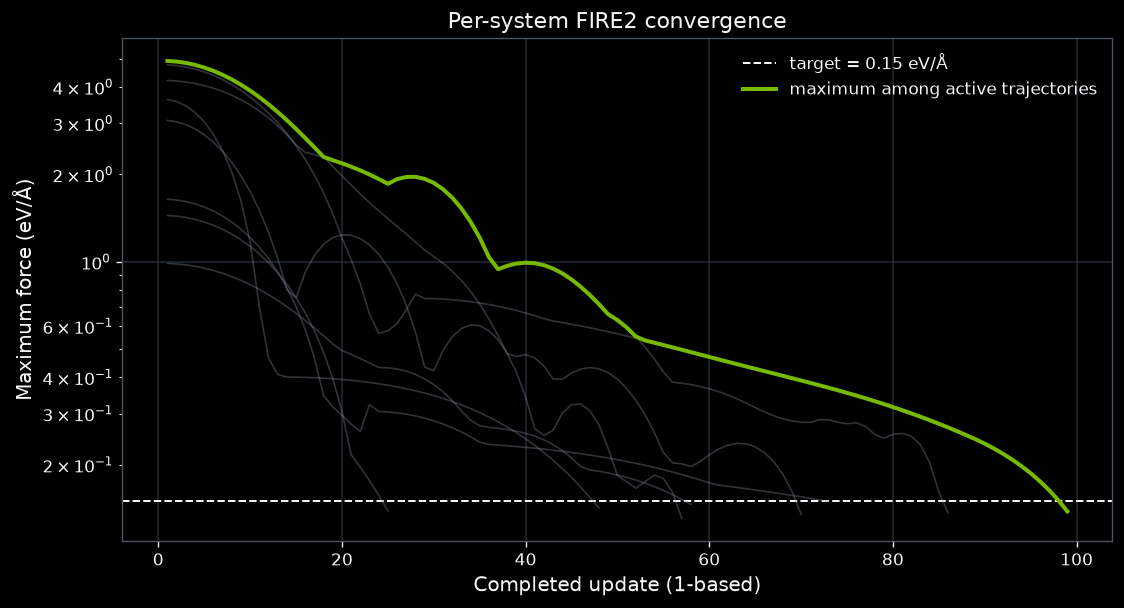

In [66]:
force_figure = helpers.plot_force_history(history, target=FMAX_TARGET_EV_A)
display(
    force_figure,
    metadata={"image/png": {"alt": "Per-system FIRE2 maximum-force histories and the shared convergence target."}},
)
plt.close(force_figure)


Each gray trajectory stops at that molecule's first converged status; update-limited systems continue to the end. The green line is the largest force among trajectories still displayed at each completed update (1-based), so later irrelevant evaluations of finished systems are excluded.

## Select and recover workflow results

A registered status-migrating hook writes status 1 for systems that crossed the target. Systems still at status 0 reached the update limit. Use the same `Batch` selection and recovery operations from Part 01 to inspect both groups.

In [67]:
relaxed_batch.status.squeeze(-1)


tensor([1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')

In [68]:
final_status = relaxed_batch.status.squeeze(-1)
converged_indices = torch.where(final_status >= 1)[0]
pending_indices = torch.where(final_status < 1)[0]


In [69]:
converged_batch = (
    relaxed_batch.index_select(converged_indices)
    if converged_indices.numel()
    else None
)
pending_batch = relaxed_batch.index_select(pending_indices) if pending_indices.numel() else None


Recover the molecule with the largest displacement and unpack every final system in source order.

In [70]:
selected_graph_index = int(per_system_results["maximum displacement (Å)"].idxmax())
selected_graph = relaxed_batch.get_data(selected_graph_index)
recovered_graphs = relaxed_batch.to_data_list()
assert [graph.num_nodes for graph in recovered_graphs] == molecule_table["atoms"].tolist()

Summarize the status groups and confirm that all eight systems were recovered.

In [71]:
selection_summary = pd.DataFrame(
    [
        {"group": "status 1 · converged", "systems": converged_indices.numel()},
        {"group": "status 0 · update limit", "systems": pending_indices.numel()},
        {"group": "recovered in source order", "systems": len(recovered_graphs)},
    ]
)

In [72]:
selection_summary

,group,systems
0,status 1 · converged,8
1,status 0 · update limit,0
2,recovered in source order,8


`index_select(...)` preserved packed Batch semantics for each status group. `get_data(...)` recovered one system, and `to_data_list()` recovered all eight in source order with their final positions, energy, forces, and status.

## Compare one structure before and after

Where did the molecule with the largest atomic displacement change?

In [73]:
start = int(relaxed_batch.batch_ptr[selected_graph_index])
stop = int(relaxed_batch.batch_ptr[selected_graph_index + 1])
initial_selected_positions = initial_positions[start:stop]
final_positions = selected_graph.positions
selected_label = LABELS[selected_graph_index]

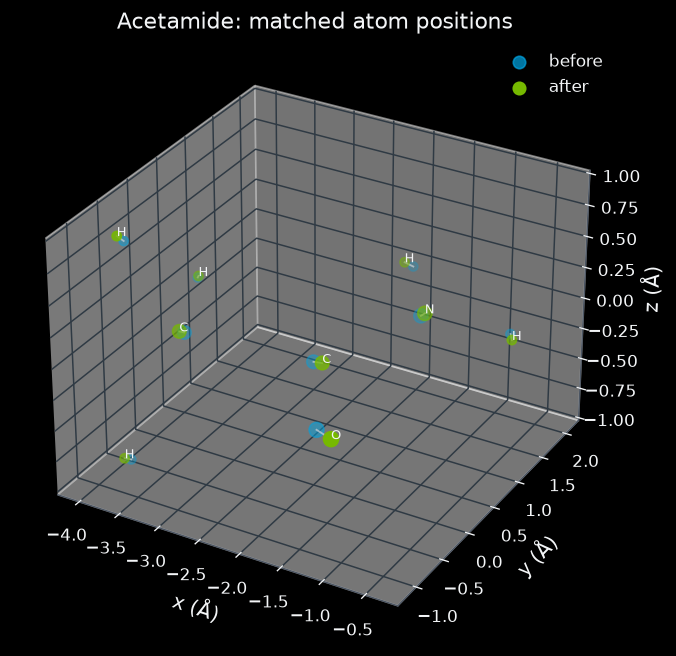

In [74]:
structure_figure = helpers.plot_structure_change(
    selected_graph.atomic_numbers, initial_selected_positions, final_positions, label=selected_label
)
display(
    structure_figure,
    metadata={"image/png": {"alt": "Matched atom positions before and after FIRE2 relaxation."}},
)
plt.close(structure_figure)

Blue marks the starting coordinates, green marks the final coordinates, and each connector follows one atom. The comparison is keyed by source-system order, not by a new matching heuristic.

## Try it: apply a stricter force target

Change `try_fmax` between `0.08` and `0.15` eV/Å. Use the public convergence detector on the final `Batch`, then select the matching systems.

In [75]:
try_fmax = 0.10
try_hook = ConvergenceHook.from_fmax(try_fmax)
try_indices = try_hook.evaluate(relaxed_batch)

In [76]:
try_selected = None if try_indices is None else relaxed_batch.index_select(try_indices)
final_fmax = helpers.per_system_fmax(relaxed_batch)
selected_fmax = final_fmax[:0] if try_indices is None else final_fmax[try_indices]
assert bool((selected_fmax <= try_fmax).all())

In [77]:
{"selected systems": len(selected_fmax), "selected fmax (eV/Å)": selected_fmax.tolist()}

{'selected systems': 0, 'selected fmax (eV/Å)': []}

Success means the selected systems satisfy the chosen target. An empty selection is valid when no final system reaches the stricter threshold.

## Recap

### What you learned

- `BaseDynamics` coordinates the hook-wrapped `pre_update → compute → post_update` lifecycle over one mutable `Batch`.
- `initialize_velocities(...)` prepares seeded, mass-aware thermal velocities; `NVE` applies Velocity Verlet; `NVTLangevin` adds a BAOAB heat bath.
- An NVE conservation diagnostic tracks potential, kinetic, and total energy. A short trace tests integration mechanics, not equilibration or production science.
- `FusedStage` uses status masks so compatible methods share one batch, one model, and one device path. Part 06 extends this to inflight execution and measurement.
- `FIRE2` requires model forces, updates positions and velocities, and protects those fields after a system finishes.
- Model-provided neighbor hooks refresh interaction data; `ConvergenceHook.from_fmax(...)` detects convergence per system and can migrate status when registered.
- A final public neighbor build plus `compute(...)` keeps energy and forces coherent with restored final positions.
- `run(...)`, `step(...)`, `index_select(...)`, `get_data(...)`, and `to_data_list()` keep execution and recovery on the public Toolkit path.

### How we will use this

Part 06 will keep compatible Toolkit stages on one GPU and measure the complete execution path. Future R&D applications can add NPT only when stress, cell evolution, equilibration, and application-specific evidence are all part of the protocol.

Course foundation: [Part 01 · AtomicData and Batch](../01-atomicdata-batch/atomicdata-and-batch.ipynb).

Prerequisite review: [Part 04 · Hooks](../04-hooks/hooks.ipynb).

Planned next lesson: **Part 06 · GPU Pipelines and Profiling**; its notebook is not yet published.